In [1]:
# Standard libraries
import os
import random

# Numerical and Data Processing
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O (e.g., pd.read_csv)

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader

# OpenCV for image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Custom utilities and configuration
from utils import visualize, analyze
from data_input import test_dataset,val_dataset,train_dataset
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# Set random seed for reproducibility
random.seed(SEED)


test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = os.listdir(test_image_path)
test_mask_list_orig = os.listdir(test_mask_path)

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = os.listdir(trainval_image_path)
trainval_mask_list_orig = os.listdir(trainval_mask_path)
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3680

# 0. Image samples Visualization

In [2]:
N = 90

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

N = 190

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

Dataset/Dataset/TrainVal/color/Abyssinian_184.jpg 
 Dataset/Dataset/TrainVal/label/Abyssinian_184.png


Dataset/Dataset/TrainVal/color/american_bulldog_192.jpg 
 Dataset/Dataset/TrainVal/label/american_bulldog_192.png


# Image Input

# 1.  Dataset preprocessing and augmentation

In [3]:


# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


c:\Users\jorge\OneDrive - unimilitar.edu.co\AI and Machine Learning\Computer_Vision\coursework\U-Net-Segmentation\data_input.py:98: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



Image batch shape: torch.Size([64, 3, 240, 240]), Mask batch shape: torch.Size([64, 240, 240])


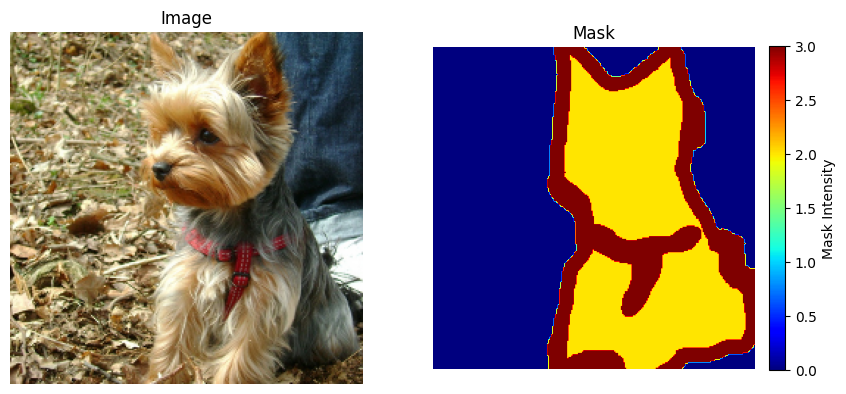

In [4]:
N=random.randint(0,BATCH_SIZE)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])

# 2. Segmentation network design and implementation

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, n_in_channels = 3, n_filters=32, dropout_prob=0, max_pooling=True):
        """
        Convolutional downsampling block

        Arguments:
            n_in_channels -- Number of input channels
            n_filters -- Number of filters for the convolutional layers
            dropout_prob -- Dropout probability
            max_pooling -- Use MaxPooling2D to reduce the spatial dimensions of the output volume
        """
        super(ConvBlock, self).__init__()

        # First Convolutional Layer
        self.conv1 = nn.Conv2d(in_channels=n_in_channels, out_channels=n_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=3, padding=1)

        # Dropout Layer (Optional)
        self.dropout = nn.Dropout2d(p=dropout_prob) if dropout_prob > 0 else None

        # Max Pooling Layer (Optional)
        self.max_pooling = nn.MaxPool2d(kernel_size=2, stride=2) if max_pooling else None

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        if self.dropout:
            x = self.dropout(x)

        skip_connection = x  # Save for the U-Net like architectures

        if self.max_pooling:
            x = self.max_pooling(x)

        return x, skip_connection
    
class UpsamplingBlock(nn.Module):
    def __init__(self, n_in_channels = 64, n_filters=32):
        """
        Convolutional upsampling block

        Arguments:
            n_in_channels -- Number of input channels
            n_filters -- Number of filters for the convolutional layers
        """
        super(UpsamplingBlock, self).__init__()

        # Transposed Convolution for upsampling
        self.upconv = nn.ConvTranspose2d(in_channels=n_in_channels, out_channels=n_filters, kernel_size=3, stride=2, padding=1, output_padding=1)

        # Convolutional layers after concatenation
        self.conv1 = nn.Conv2d(in_channels=n_filters * 2, out_channels=n_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=3, padding=1)

    def forward(self, expansive_input, contractive_input):
        print("Expansive input: ",expansive_input.shape)
        up = self.upconv(expansive_input)
        print("up: ",up.shape)
        # Ensure spatial sizes match before concatenation
        diffY = contractive_input.size()[2] - up.size()[2]
        diffX = contractive_input.size()[3] - up.size()[3]
        up = F.pad(up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])

        # Concatenate along the channel dimension
        merge = torch.cat([up, contractive_input], dim=1)

        # Apply convolutions
        conv = F.relu(self.conv1(merge))
        conv = F.relu(self.conv2(conv))

        return conv

class UNet(nn.Module):
    def __init__(self, input_channels=3, n_filters=32, n_classes=4):
        """
        UNet model

        Arguments:
            input_channels -- Number of input channels (default: 3 for RGB images)
            n_filters -- Number of filters for the convolutional layers
            n_classes -- Number of output classes
        """
        super(UNet, self).__init__()
        print("UNet Model initialized")
        # Contracting Path (Encoder)
        self.cblock1 = ConvBlock(n_in_channels=input_channels, n_filters=n_filters)
        self.cblock2 = ConvBlock(n_in_channels=n_filters, n_filters=n_filters * 2)
        self.cblock3 = ConvBlock(n_in_channels=n_filters * 2, n_filters=n_filters * 4)
        self.cblock4 = ConvBlock(n_in_channels=n_filters * 4, n_filters=n_filters * 8, dropout_prob=0.3)
        self.cblock5 = ConvBlock(n_in_channels=n_filters * 8, n_filters=n_filters * 16, dropout_prob=0.3, max_pooling=False)

        # Expanding Path (Decoder)
        self.ublock6 = UpsamplingBlock(n_in_channels=n_filters * 16, n_filters=n_filters * 8)
        self.ublock7 = UpsamplingBlock(n_in_channels=n_filters * 8, n_filters=n_filters * 4)
        self.ublock8 = UpsamplingBlock(n_in_channels=n_filters * 4, n_filters=n_filters * 2)
        self.ublock9 = UpsamplingBlock(n_in_channels=n_filters * 2, n_filters=n_filters)


        # Final Convolutional Layers
        self.conv9 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=3, padding=1)
        self.conv10 = nn.Conv2d(in_channels=n_filters, out_channels=n_classes, kernel_size=1)

    def forward(self, x):
        print("Forward pass")
        print("x: ",x.shape)
        # Encoder
        cblock1, skip1 = self.cblock1(x)
        print("cblock1: ",cblock1.shape)
        cblock2, skip2 = self.cblock2(cblock1)
        print("cblock2: ",cblock2.shape)
        cblock3, skip3 = self.cblock3(cblock2)
        print("cblock3: ",cblock3.shape)
        cblock4, skip4 = self.cblock4(cblock3)
        print("cblock4: ",cblock4.shape)
        cblock5, _ = self.cblock5(cblock4)  # No skip connection for last layer
        print("cblock5: ",cblock5.shape)
        # Decoder
        print("DECODER")
        print("skip4: ",skip4.shape)
        print("cblock5: ",cblock5.shape)
        ublock6 = self.ublock6(cblock5, skip4)
        ublock7 = self.ublock7(ublock6, skip3)
        ublock8 = self.ublock8(ublock7, skip2)
        ublock9 = self.ublock9(ublock8, skip1)

        # Final convolutions
        conv9 = F.relu(self.conv9(ublock9))
        conv10 = self.conv10(conv9)  # No activation (typically softmax is applied externally)

        return conv10

In [38]:
model = UNet(input_channels=3, n_filters=32, n_classes=23)
x = torch.randn(1, 3, 96, 128)  # Example input (batch size=1)
output = model(x)
print(output.shape)  # Expected: (1, 23, 96, 128)


UNet Model initialized
Forward pass
x:  torch.Size([1, 3, 96, 128])
cblock1:  torch.Size([1, 32, 48, 64])
cblock2:  torch.Size([1, 64, 24, 32])
cblock3:  torch.Size([1, 128, 12, 16])
cblock4:  torch.Size([1, 256, 6, 8])
cblock5:  torch.Size([1, 512, 6, 8])
DECODER
skip4:  torch.Size([1, 256, 12, 16])
cblock5:  torch.Size([1, 512, 6, 8])
Expansive input:  torch.Size([1, 512, 6, 8])
up:  torch.Size([1, 256, 12, 16])
Expansive input:  torch.Size([1, 256, 12, 16])
up:  torch.Size([1, 128, 24, 32])
Expansive input:  torch.Size([1, 128, 24, 32])
up:  torch.Size([1, 64, 48, 64])
Expansive input:  torch.Size([1, 64, 48, 64])
up:  torch.Size([1, 32, 96, 128])
torch.Size([1, 23, 96, 128])
